In [ ]:
import zipfile

with zipfile.ZipFile("waste_dataset.zip", "r") as zip_ref:
    zip_ref.extractall("/content/")

In [48]:
import os

DATA_DIR = "/content/Data/Garbage_Classification"

print(os.listdir(DATA_DIR))

['Plastic', 'Battery', 'Glass', 'Clothes', 'Paper', 'Cardboard', 'Metal']


In [49]:
for class_name in os.listdir(DATA_DIR):
    class_path = os.path.join(DATA_DIR, class_name)

    if os.path.isdir(class_path):
        print(class_name, ":", len(os.listdir(class_path)))

Plastic : 385
Battery : 775
Glass : 775
Clothes : 432
Paper : 594
Cardboard : 403
Metal : 769


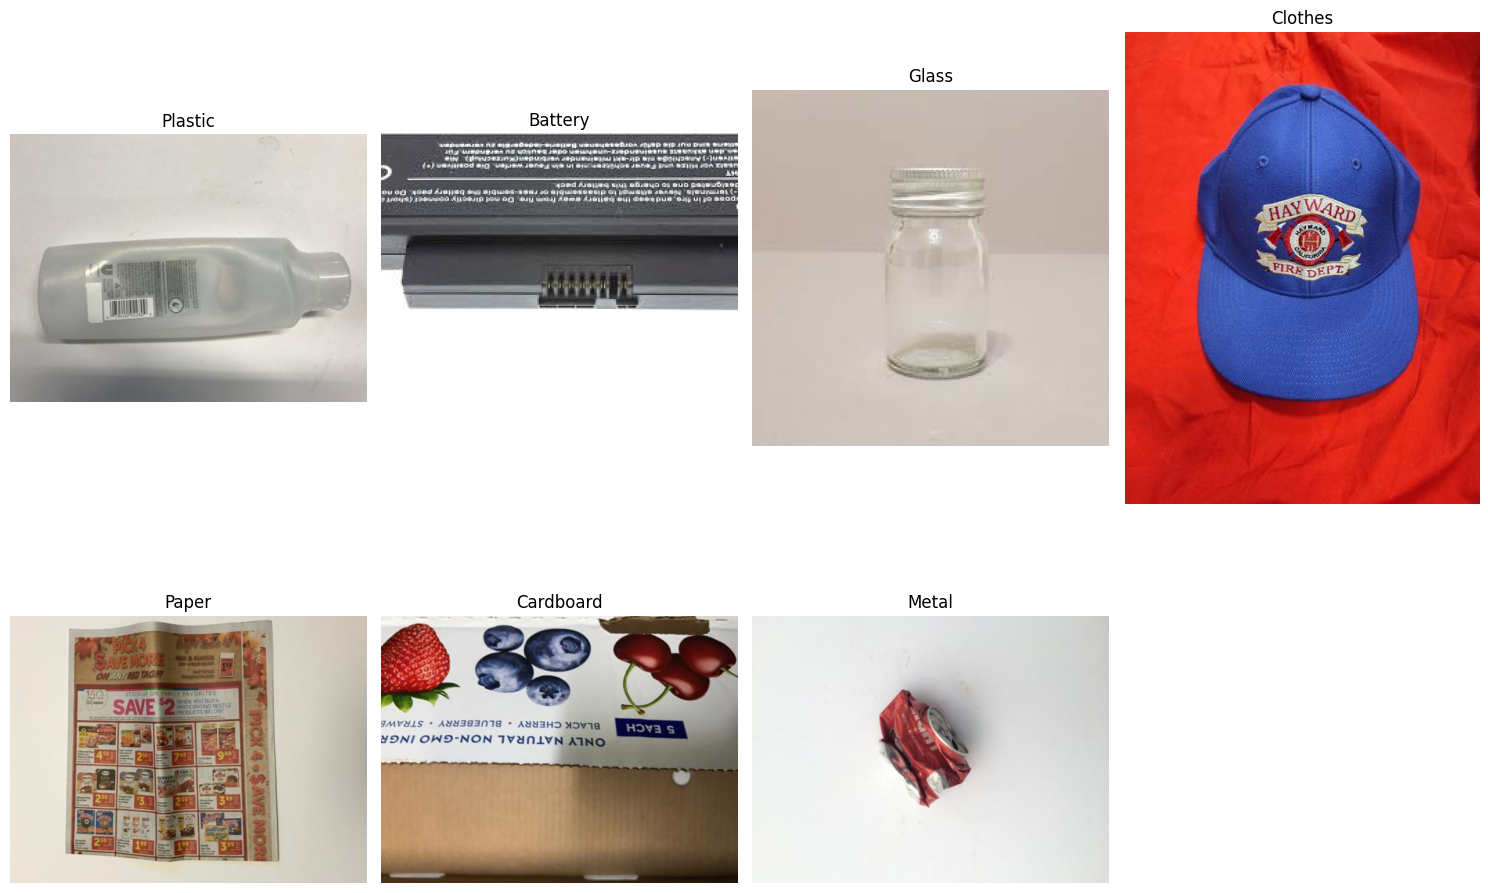

In [50]:
import matplotlib.pyplot as plt
import os
from PIL import Image

classes = os.listdir(DATA_DIR)

plt.figure(figsize=(15, 10))

for i, class_name in enumerate(classes):
    class_path = os.path.join(DATA_DIR, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [51]:
import tensorflow as tf

img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

Found 4133 files belonging to 7 classes.
Using 3307 files for training.
Found 4133 files belonging to 7 classes.
Using 826 files for validation.


In [52]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


In [53]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    Rescaling
)

In [54]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [55]:
model = Sequential([
    data_augmentation,
    Rescaling(1./255, input_shape=(224, 224, 3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [56]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [57]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [58]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    mode='max',
    restore_best_weights=True
)

In [59]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - accuracy: 0.3490 - loss: 1.7481 - val_accuracy: 0.4818 - val_loss: 1.3304
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.4811 - loss: 1.3508 - val_accuracy: 0.5012 - val_loss: 1.2444
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.5761 - loss: 1.1825 - val_accuracy: 0.5339 - val_loss: 1.2630
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.6011 - loss: 1.0892 - val_accuracy: 0.5847 - val_loss: 1.1274
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.6302 - loss: 1.0138 - val_accuracy: 0.6150 - val_loss: 1.0472
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.6465 - loss: 0.9860 - val_accuracy: 0.6525 - val_loss: 0.9395
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.6586 - loss: 0.9482 - val_accuracy: 0.6695 - val_loss: 0.8996
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.6728 - loss: 0.9180 - val_a

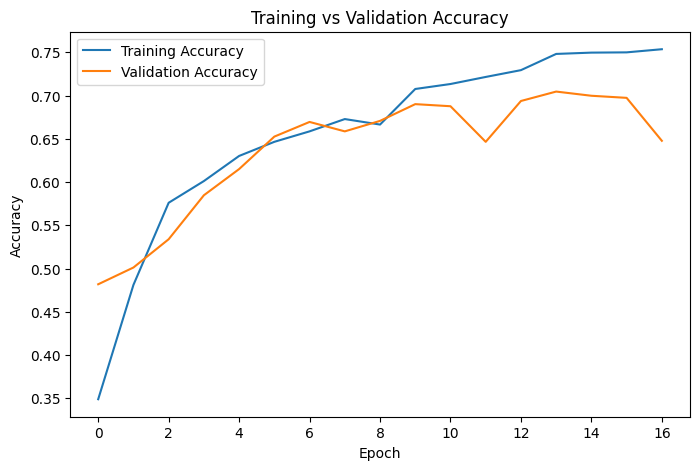

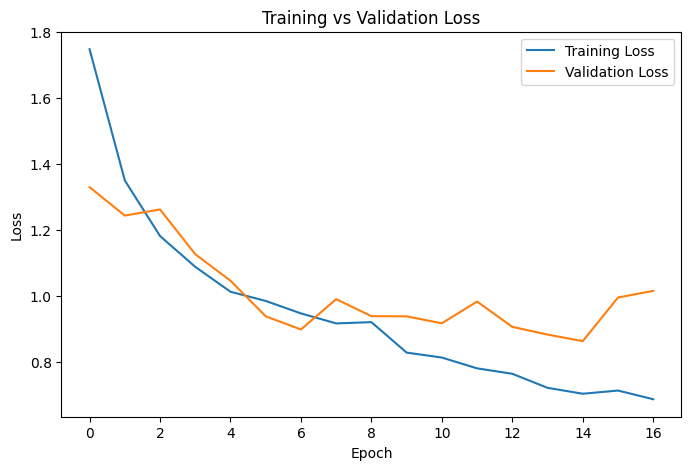

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [61]:
val_loss, val_accuracy = model.evaluate(val_ds)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7046 - loss: 0.8841
Validation Loss: 0.8841333985328674
Validation Accuracy: 0.7046005129814148


In [62]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [63]:
class_names = ['Battery', 'Cardboard', 'Clothes', 'Glass',
 'Metal', 'Paper', 'Plastic']

In [64]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

     Battery       0.83      0.84      0.84       139
   Cardboard       0.92      0.65      0.76        92
     Clothes       0.87      0.75      0.80        79
       Glass       0.64      0.70      0.67       143
       Metal       0.58      0.62      0.60       168
       Paper       0.64      0.86      0.73       111
     Plastic       0.68      0.50      0.58        94

    accuracy                           0.70       826
   macro avg       0.74      0.70      0.71       826
weighted avg       0.72      0.70      0.70       826



In [65]:
#Transfer learning
#Using MobileNet
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

In [66]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [67]:
model_mobile = Sequential([
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

In [68]:
model_mobile.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [69]:
history_mobile = model_mobile.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step - accuracy: 0.5077 - loss: 1.3920 - val_accuracy: 0.6162 - val_loss: 1.1238
Epoch 2/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.6181 - loss: 1.0746 - val_accuracy: 0.6308 - val_loss: 1.0676
Epoch 3/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.6486 - loss: 1.0024 - val_accuracy: 0.6598 - val_loss: 0.9595


In [70]:
val_loss, val_accuracy = model_mobile.evaluate(val_ds)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.6162 - loss: 1.1238
Validation Loss: 1.1238131523132324
Validation Accuracy: 0.6162227392196655


In [71]:
base_model.trainable = True

In [72]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [73]:
model_mobile.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [74]:
history_fine = model_mobile.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 22s 108ms/step - accuracy: 0.4221 - loss: 1.6846 - val_accuracy: 0.6126 - val_loss: 1.1356
Epoch 2/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.5168 - loss: 1.3350 - val_accuracy: 0.6199 - val_loss: 1.1516
Epoch 3/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.5757 - loss: 1.1978 - val_accuracy: 0.6114 - val_loss: 1.1618


In [75]:
val_loss, val_accuracy = model_mobile.evaluate(val_ds)

print("Fine-tuned Validation Loss:", val_loss)
print("Fine-tuned Validation Accuracy:", val_accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.6126 - loss: 1.1356
Fine-tuned Validation Loss: 1.1356451511383057
Fine-tuned Validation Accuracy: 0.6125907897949219


In [76]:
#Using EfficientNet
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0

In [77]:
base_model2 = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [78]:
base_model2.trainable = False

In [79]:
model_eff = Sequential([
    data_augmentation,
    base_model2,

    tf.keras.layers.GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

In [80]:
model_eff.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [89]:
history_eff = model_eff.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - accuracy: 0.2997 - loss: 1.7861 - val_accuracy: 0.5036 - val_loss: 1.5909
Epoch 2/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - accuracy: 0.4439 - loss: 1.6059 - val_accuracy: 0.6332 - val_loss: 1.4173
Epoch 3/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - accuracy: 0.5513 - loss: 1.4352 - val_accuracy: 0.6985 - val_loss: 1.2552


In [90]:
val_loss, val_accuracy = model_eff.evaluate(val_ds)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.5036 - loss: 1.5909
Validation Loss: 1.5909409523010254
Validation Accuracy: 0.5036319494247437


In [92]:
base_model2.trainable = True

In [93]:
for layer in base_model2.layers[:-30]:
    layer.trainable = False

In [94]:
model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [95]:
history_fine2 = model_eff.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 31s 140ms/step - accuracy: 0.4521 - loss: 1.5957 - val_accuracy: 0.6416 - val_loss: 1.4109
Epoch 2/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 12s 114ms/step - accuracy: 0.5582 - loss: 1.4244 - val_accuracy: 0.7034 - val_loss: 1.2428
Epoch 3/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 13s 122ms/step - accuracy: 0.6172 - loss: 1.2759 - val_accuracy: 0.7542 - val_loss: 1.0836
Epoch 4/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 20s 113ms/step - accuracy: 0.6873 - loss: 1.1266 - val_accuracy: 0.7833 - val_loss: 0.9484
Epoch 5/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 21s 115ms/step - accuracy: 0.7194 - loss: 1.0154 - val_accuracy: 0.8063 - val_loss: 0.8307
Epoch 6/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - accuracy: 0.7690 - loss: 0.8834 - val_accuracy: 0.8196 - val_loss: 0.7342
Epoch 7/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 12s 114ms/step - accuracy: 0.7617 - loss: 0.8242 - val_accuracy: 0.8402 - val_loss: 0.6578
Epoch 8/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.7802 - loss: 0

In [96]:
val_loss, val_accuracy = model_eff.evaluate(val_ds)

print("Fine-tuned Validation Loss:", val_loss)
print("Fine-tuned Validation Accuracy:", val_accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.9031 - loss: 0.3634
Fine-tuned Validation Loss: 0.3634053170681
Fine-tuned Validation Accuracy: 0.9031476974487305


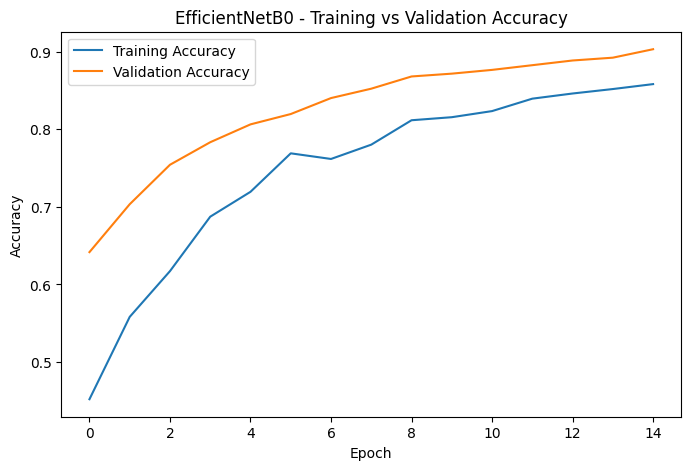

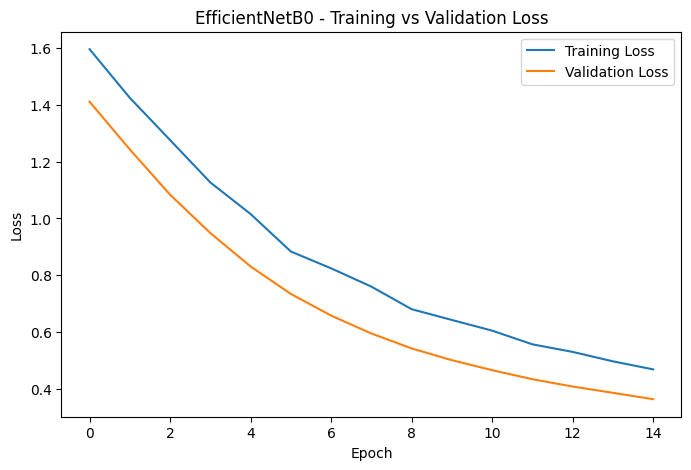

In [97]:
plt.figure(figsize=(8, 5))

plt.plot(history_fine2.history['accuracy'], label='Training Accuracy')
plt.plot(history_fine2.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('EfficientNetB0 - Training vs Validation Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(history_fine2.history['loss'], label='Training Loss')
plt.plot(history_fine2.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('EfficientNetB0 - Training vs Validation Loss')
plt.legend()
plt.show()

In [98]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model_eff.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

     Battery       0.96      0.96      0.96       139
   Cardboard       0.98      0.86      0.91        92
     Clothes       0.94      0.99      0.96        79
       Glass       0.88      0.88      0.88       143
       Metal       0.85      0.92      0.88       168
       Paper       0.89      0.91      0.90       111
     Plastic       0.90      0.78      0.83        94

    accuracy                           0.90       826
   macro avg       0.91      0.90      0.90       826
weighted avg       0.90      0.90      0.90       826



In [99]:
model_eff.save("waste_classifier.keras")

In [100]:
import json

with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

print("Class names saved to 'class_names.json'")

Class names saved to 'class_names.json'
